In [ ]:
import torch
import random
import sys
import os
import matplotlib.pyplot as plt
from plot import plot2Dimage, plot2Dimage2
import numpy as np
import scipy.io
from gmres import mygmres2dtorch
from RTE_datagenerator import RTECoef
from RTE_ATFPS_func import generate_TFPS_rhs_Dirichlet_iso, func_inflow_Dirichlet, funcDinv, funcDc, restrict_basis, correction
from RTE_datagenerator import fun_value
from RTE_mgmodel import MG_precond
from utils import check_chinese_font

In [2]:
size, num_coef, N = 16, 16, 1
data_type = 'diffusion'
device = 'cuda:1'
# tolerance for ATFPS threshold, when tol_exp=5, delta=10^(-5)
tol_exp = 5 
tol = tol_exp*np.log(10)
batch_size = 256

# generate path for neural model
current_dir = os.getcwd() 
quadrature_path = current_dir + '/discretized_parameters/quadrature2DN'+str(N)+'.mat'
Kappa_path =  current_dir + '/discretized_parameters/KappaN'+str(N)+'g0.mat'
sub_dir = '/CosineAnnealingLR_T_max100/lr0.001/'

# num_epoch is specially selected based on the training loss figure
num_epochs1 = 879
fn1 = data_type+'I'+str(size)+'N'+str(N)+'L4batch'+str(batch_size)+'epoch'+str(num_epochs1)+'d100010000tol'+str(tol_exp)+'_multilevel'
num_epochs2 = 661
fn2 = data_type+'I'+str(size)+'N'+str(N)+'L4batch'+str(batch_size)+'epoch'+str(num_epochs2)+'d200020000tol'+str(tol_exp)+'_multilevel'



In [3]:
# generate test data
test_size = 16
test_num_coef = 10
quadrature = scipy.io.loadmat(quadrature_path)
ct = torch.tensor(quadrature['ct']).squeeze(-1).to(device)
st = torch.tensor(quadrature['st']).squeeze(-1).to(device)
omega = torch.tensor(quadrature['omega']).squeeze(-1).to(device)
M = quadrature['M'].item()
Kappa = torch.tensor(scipy.io.loadmat(Kappa_path)['Kappa']).to(device)
CoefData = RTECoef(test_size, test_num_coef, data_type, device)
[Coef, fsmLRBTC, I2A, MLRBT, VecSize] = CoefData.getinfo(M, ct, st, omega, Kappa, tol)
RTEData = {
    'Coef': Coef,
    'fsmLRBTC': fsmLRBTC,
    'I2A': I2A,
    'MLRBT': MLRBT,
    'VecSize': VecSize,
}
# right hand side
n = 3
Q_pre = torch.rand((test_num_coef, 2, n)).to(device)
Q_pre[:,:,0] = Q_pre[:,:,0] + 1
Q_pre[:,:,1:n] = 2*Q_pre[:,:,1:n] -1 
Q = fun_value(test_size, test_size, 0, 1, 0, 1, Q_pre, device).unsqueeze(1).repeat(1,4*M, 1, 1)
psiL, psiR, psiB, psiT = torch.ones([test_num_coef, 2*M, test_size]).to(device), torch.ones([test_num_coef, 2*M, test_size]).to(device), torch.ones([test_num_coef, 2*M, test_size]).to(device), torch.ones([test_num_coef, 2*M, test_size]).to(device)
[rhs_selected, rhs_unselected, vec] = generate_TFPS_rhs_Dirichlet_iso(Q, psiL, psiR, psiB, psiT, Coef,  Kappa, omega, MLRBT, VecSize, M, test_size, test_size, device)



data type: diffusion
offline assembling completed using 3.1396 seconds!


tensor(0.0022, device='cuda:1') tensor(0.0022, device='cuda:1')


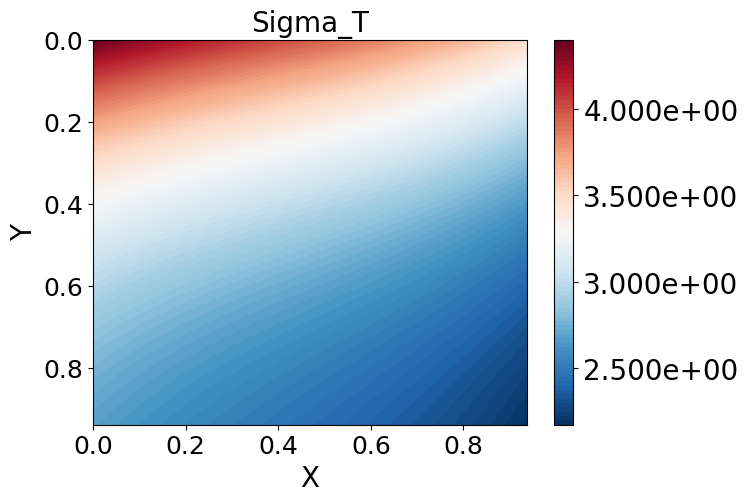

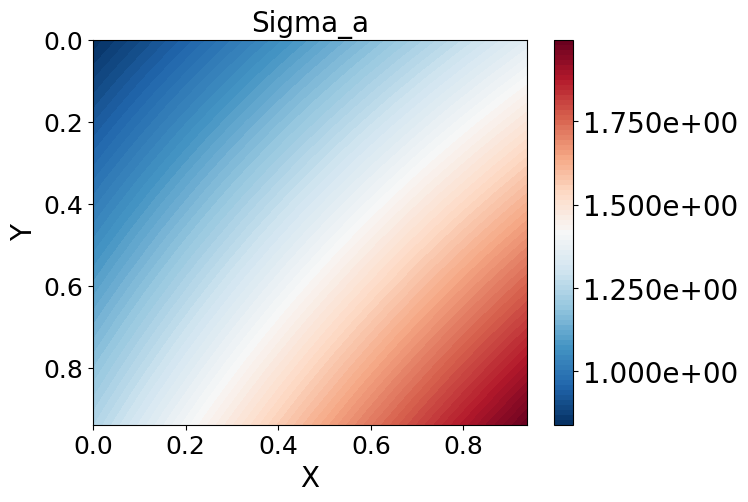

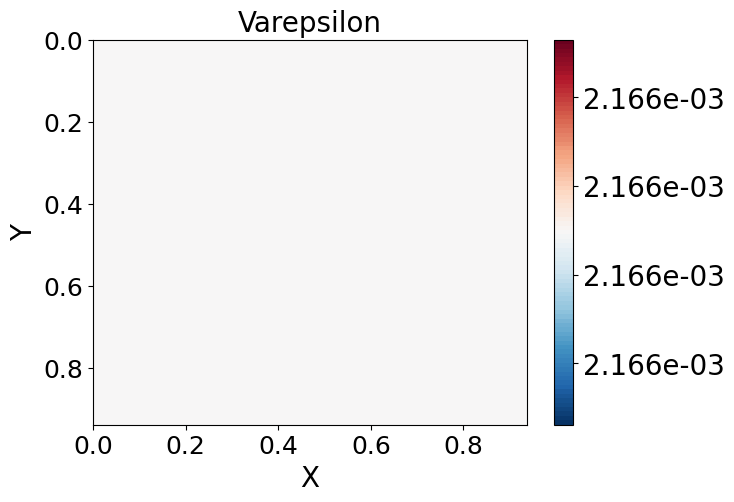

In [4]:
# show example
ins = 2
Sigma_T, Sigma_a, Varepsilon = Coef[ins,0], Coef[ins,1], torch.exp(Coef[ins,2])
print(torch.min(Varepsilon), torch.max(Varepsilon))
plot2Dimage2(0, test_size, 0, test_size, 1/test_size, Sigma_T.cpu(), title="Sigma_T", font_size=20)
plot2Dimage2(0, test_size, 0, test_size, 1/test_size, Sigma_a.cpu(), title="Sigma_a", font_size=20)
plot2Dimage2(0, test_size, 0, test_size, 1/test_size, Varepsilon.cpu(), title="Varepsilon", font_size=20)

Iteration: 49, Residual norm: 1.793699e-03, Relative residual norm: 8.937134e-05
>>> residual norm:  0.002036504680290818


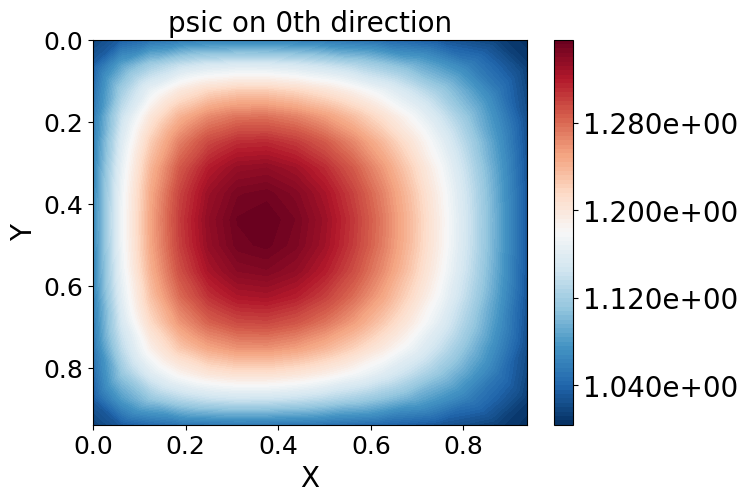

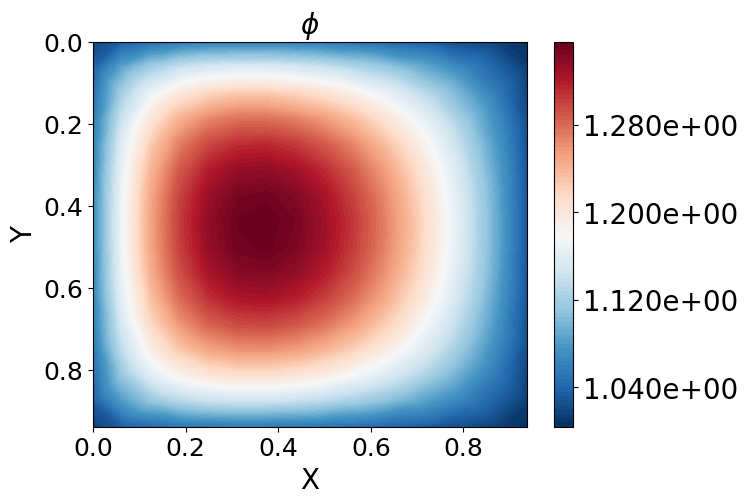

In [5]:
# the system in neural network
# use classical method
solver = mygmres2dtorch(lambda value: funcDinv(value, I2A, fsmLRBTC, MLRBT, VecSize, M, test_size, test_size, device), lambda value: func_inflow_Dirichlet(value, I2A, fsmLRBTC, MLRBT, VecSize, M, test_size, test_size, device))
inflow1,history1=solver.solve(rhs_selected, tol = 10**(-4), max_iter = 300, verbose=False)
psic1 = funcDc(inflow1, vec, I2A, fsmLRBTC, M, test_size, test_size)
phic1 = torch.einsum('bmij, m->bij', psic1, omega.to(torch.float32))
rhs1 = rhs_selected - func_inflow_Dirichlet(inflow1, I2A, fsmLRBTC, MLRBT, VecSize, M, test_size, test_size, device)

# check_chinese_font()
# plt.figure(figsize=(8, 5))
# plt.semilogy(history1)
# plt.xlabel('迭代次数', fontsize=14)
# plt.ylabel('相对残差', fontsize=14)
# plt.xticks(fontsize=12) 
# plt.yticks(fontsize=12) 

# show solution over the whole domain
direction = 0
plot2Dimage2(0, test_size, 0, test_size, 1/test_size, psic1[ins,direction,:,:].cpu(),title="psic on "+str(direction)+"th direction", font_size=20)
plot2Dimage2(0, size, 0, size, 1/size, phic1[ins].cpu().detach(),title="$\phi$", font_size=20)

In [6]:
# use GMRES with trained preconditioner (10000 samples)
u_channels_list=[16, 32, 64, 128]
a_channels_list=[16, 32, 64, 128]
mg_levels=[2, 2, 2, 4]
model_path = current_dir+'/model_precond' +sub_dir + fn1 + '.pt'

# for loss that only consider selected velocity modes
def precond_model_corrected(rhs):
    inflow = precond_model(rhs,a_list, inv_a_list)
    [_, rhs_unselected] = restrict_basis(rhs, VecSize, M, test_size, test_size, device)
    [_, inflow_corrected, _] = correction(inflow, rhs_unselected, I2A, fsmLRBTC, MLRBT, VecSize, M, test_size, test_size, device)
    return inflow_corrected

precond_model = MG_precond(M, u_channels_list, a_channels_list, mg_levels).to(device)
precond_model.load_state_dict(torch.load(model_path,weights_only=True))
precond_model.eval()
[a_list, inv_a_list] = precond_model.setup(Coef)
# solver = mygmres2dtorch(precond_model, lambda value: func_inflow_Dirichlet(value, I2A, fsmLRBTC, MLRBT, VecSize, M, I0, J0, device))
solver = mygmres2dtorch(precond_model_corrected, lambda value: func_inflow_Dirichlet(value, I2A, fsmLRBTC, MLRBT, VecSize, M, test_size, test_size, device))
print(rhs_selected.shape)
inflow2,history2=solver.solve(rhs_selected, tol = 10**(-4), max_iter = 300, verbose=False)
psic2 = funcDc(inflow2, vec, I2A, fsmLRBTC, M, test_size, test_size, device)
phic2 = torch.einsum('bmij, m->bij', psic2, omega.to(torch.float32))
rhs2 = rhs_selected - func_inflow_Dirichlet(inflow2, I2A, fsmLRBTC, MLRBT, VecSize, M, test_size, test_size, device)



# check_chinese_font()
# plt.figure(figsize=(8, 5))
# plt.semilogy(history2)
# plt.xlabel('迭代次数', fontsize=14)
# plt.ylabel('相对残差', fontsize=14)
# plt.xticks(fontsize=12) 
# plt.yticks(fontsize=12) 

# # show solution over the whole domain
# plot2Dimage2(0, size, 0, size, 1/size, psic2[ins,direction,:,:].cpu().detach(),title="psic on "+str(direction)+"th direction", font_size=20)
# plot2Dimage2(0, size, 0, size, 1/size, phic2[ins].cpu().detach(),title="$\phi$", font_size=20)

torch.Size([10, 8, 16, 16])
Iteration: 5, Residual norm: 1.100546e-03, Relative residual norm: 5.483488e-05
>>> residual norm:  0.0017350997077301145


In [7]:
# use GMRES with trained preconditioner (20000 samples)
u_channels_list=[16, 32, 64, 128]
a_channels_list=[16, 32, 64, 128]
mg_levels=[2, 2, 2, 4]
# num_epoch is specially selected based on the training loss figure
model_path = current_dir+'/model_precond' +sub_dir + fn2 + '.pt'


# for loss that only consider selected velocity modes
def precond_model_corrected(rhs):
    inflow = precond_model(rhs, a_list, inv_a_list)
    [_, rhs_unselected] = restrict_basis(rhs, VecSize, M, test_size, test_size, device)
    [_, inflow_corrected, _] = correction(inflow, rhs_unselected, I2A, fsmLRBTC, MLRBT, VecSize, M, test_size, test_size, device)
    return inflow_corrected

precond_model = MG_precond(M, u_channels_list, a_channels_list, mg_levels).to(device)
precond_model.load_state_dict(torch.load(model_path,weights_only=True))
precond_model.eval()
[a_list, inv_a_list] = precond_model.setup(Coef)
# solver = mygmres2dtorch(precond_model, lambda value: func_inflow_Dirichlet(value, I2A, fsmLRBTC, MLRBT, VecSize, M, I0, J0, device))
solver = mygmres2dtorch(precond_model_corrected, lambda value: func_inflow_Dirichlet(value, I2A, fsmLRBTC, MLRBT, VecSize, M, test_size, test_size, device))
print(rhs_selected.shape)
inflow3,history3=solver.solve(rhs_selected, tol = 10**(-4), max_iter = 300, verbose=False)
psic3 = funcDc(inflow3, vec, I2A, fsmLRBTC, M, test_size, test_size, device)
phic3 = torch.einsum('bmij, m->bij', psic3, omega.to(torch.float32))
rhs3 = rhs_selected - func_inflow_Dirichlet(inflow3, I2A, fsmLRBTC, MLRBT, VecSize, M, test_size, test_size, device)



# check_chinese_font()
# plt.figure(figsize=(8, 5))
# plt.semilogy(history2)
# plt.xlabel('迭代次数', fontsize=14)
# plt.ylabel('相对残差', fontsize=14)
# plt.xticks(fontsize=12) 
# plt.yticks(fontsize=12) 

# # show solution over the whole domain
# plot2Dimage2(0, size, 0, size, 1/size, psic2[ins,direction,:,:].cpu().detach(),title="psic on "+str(direction)+"th direction", font_size=20)
# plot2Dimage2(0, size, 0, size, 1/size, phic2[ins].cpu().detach(),title="$\phi$", font_size=20)



torch.Size([10, 8, 16, 16])
Iteration: 5, Residual norm: 1.692932e-03, Relative residual norm: 8.435057e-05
>>> residual norm:  0.002074415795505047


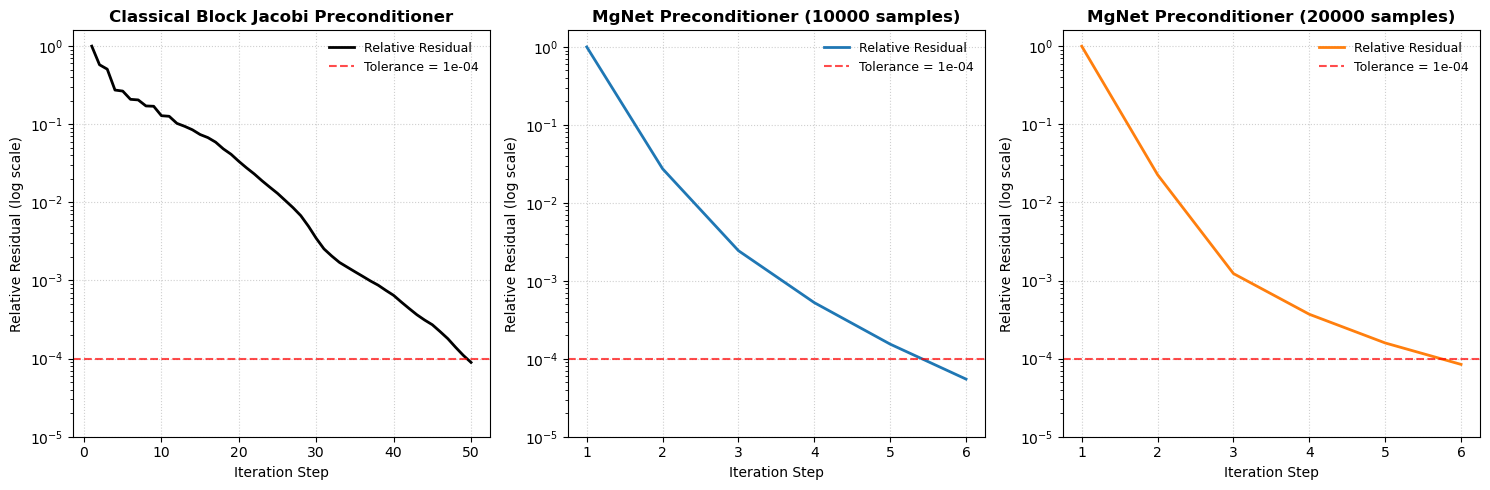

In [8]:
# 三种preconditioner的GMRES迭代情况一起画
# ========================= 参数配置 =========================
# 子图标题
titles = [
    'Classical Block Jacobi Preconditioner',
    'MgNet Preconditioner (10000 samples)',
    'MgNet Preconditioner (20000 samples)'
]

# 线条颜色
colors = ["#000000",'#1f77b4', '#ff7f0e']

# 线条宽度
line_width = 2

# 是否显示网格
show_grid = True

# 图像尺寸（宽，高），单位英寸
figsize = (15, 5)

# 收敛阈值线（如果有，可以显示一条水平线表示10^-4）
show_tolerance_line = True
tolerance = 1e-4
tolerance_label = f'Tolerance = {tolerance:.0e}'

# # 保存图片的文件名（可修改）
# save_filename = 'gmres_residual_1x3.png'
# dpi = 300

# ========================= 绘图 =========================
fig, axes = plt.subplots(1, 3, figsize=figsize)

# 将所有历史数据放入列表以便遍历
histories = [history1, history2, history3]

for idx, ax in enumerate(axes):
    hist = histories[idx]
    iterations = np.arange(1, len(hist) + 1)   # 迭代步数从1开始
    residuals = np.array(hist)
    
    # 绘制残差曲线
    ax.semilogy(iterations, residuals, color=colors[idx], linewidth=line_width, label='Relative Residual')
    
    # 设置标题
    ax.set_title(titles[idx], fontsize=12, fontweight='bold')
    
    # 坐标轴标签
    ax.set_xlabel('Iteration Step', fontsize=10)
    ax.set_ylabel('Relative Residual (log scale)', fontsize=10)
    
    # 网格
    if show_grid:
        ax.grid(True, linestyle=':', alpha=0.6)
    
    # 添加收敛阈值线
    if show_tolerance_line:
        ax.axhline(y=tolerance, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=tolerance_label)
    
    # 图例
    ax.legend(loc='upper right', frameon=False, fontsize=9)
    
    if len(residuals) > 0:
        # 取残差最小值和 tolerance*0.1 中的较小值作为下限（不能为0）
        y_min = min(min(residuals), tolerance * 0.1)
        # 避免对数为负无穷（如果最小值是0，就给一个很小的正数）
        if y_min <= 0:
            y_min = 1e-8
        ax.set_ylim(bottom=y_min)
    else:
        ax.set_ylim(bottom=tolerance * 0.1)

# 整体调整布局
plt.tight_layout()

# # 保存图片
# plt.savefig(save_filename, dpi=dpi, bbox_inches='tight')
# print(f"图片已保存至：{save_filename}")

# 如需显示（在交互式环境中可取消注释）
plt.show()
plt.close()